In [11]:
# Import

import pandas as pd
import numpy as np
import seaborn as sns

In [12]:
# Set this to True if you want to save figures/data, and False otherwise

save_output = True

In [13]:
classifiers = ['XGB', 'LR', 'RF', 'MLP', 'SVM', 'AB', 'ET', 'LGBM']
feature_selectors = ['none', 'mrmr', 'ffs', 'bfs', 'rfecv']

In [14]:
# LIST OF DATAFRAMES

# Initialize an empty list to hold the DataFrames
dataframes = []

# Create 7 DataFrames and add them to the list
for i in range(7):
    df = pd.DataFrame(index=classifiers, columns=feature_selectors, dtype=float)
    dataframes.append(df)

In [15]:
# FILLING THE DATAFRAMES

# Mapping from the full class names stored in results.xlsx to the short
# display names used as row labels in the heatmaps.

# Columns to read for each of the 7 dataframes
SCORE_COLUMNS = [
    'cv_f1_mean',              # 0 – F1 CV
    'train f1_weighted',       # 1 – F1 Train
    'test f1_weighted',        # 2 – F1 Test
    'test balanced_accuracy',  # 5 – Accuracy Test
    'test auc',                # 6 – AUC Test
    'test sensitivity',        # 7 – Sensitivity Test
    'test specificity',        # 8 – Specificity Test
]

# Feature selectors available for each model (rfecv only for some models)
feature_selectors_by_model = {
    'XGB': ['none', 'mrmr', 'ffs', 'bfs', 'rfecv'],
    'LR': ['none', 'mrmr', 'ffs', 'bfs'],
    'RF': ['none', 'mrmr', 'ffs', 'bfs', 'rfecv'],
    'MLP': ['none', 'mrmr', 'ffs', 'bfs'],
    'SVM': ['none', 'mrmr', 'ffs', 'bfs'],
    'AB': ['none', 'mrmr', 'ffs', 'bfs'],
    'ET': ['none', 'mrmr', 'ffs', 'bfs', 'rfecv'],
    'LGBM': ['none', 'mrmr', 'ffs', 'bfs', 'rfecv'],
}

results = pd.read_excel('Results/classif_results.xlsx')

# Drop duplicates — keep the last run (consistent with incremental saving)
results = results.drop_duplicates(subset=['model', 'fs'], keep='last')

for cl in classifiers:
    for fs in feature_selectors_by_model.get(cl, []):
        row = results[(results['model'] == cl) & (results['fs'] == fs)]
        for i, col in enumerate(SCORE_COLUMNS):
            if col is None or row.empty:
                dataframes[i].loc[cl, fs] = np.nan
            else:
                dataframes[i].loc[cl, fs] = row[col].values[0]

In [16]:
# Converting the dataframes from object to float
for i in range(7):
    dataframes[i] = dataframes[i].astype(float)

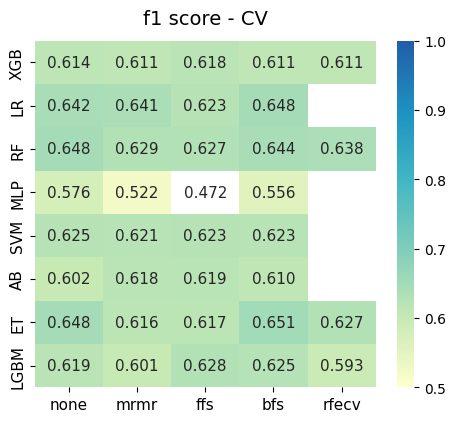

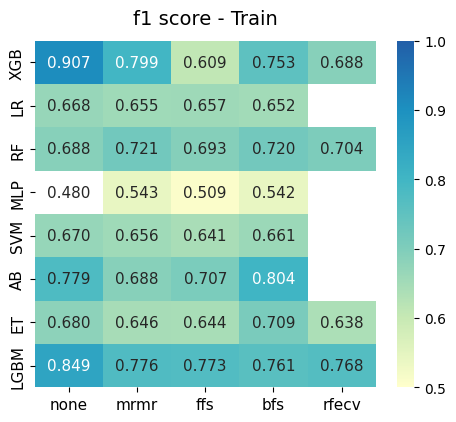

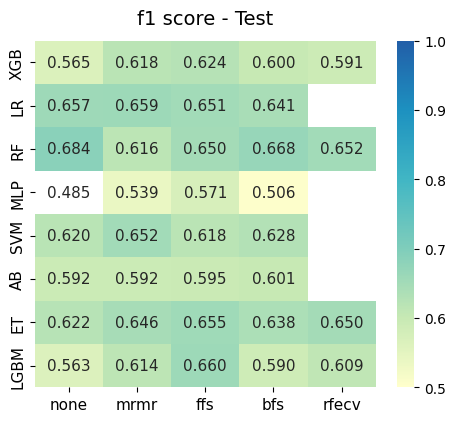

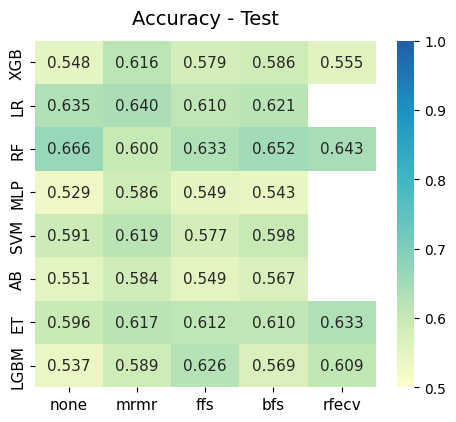

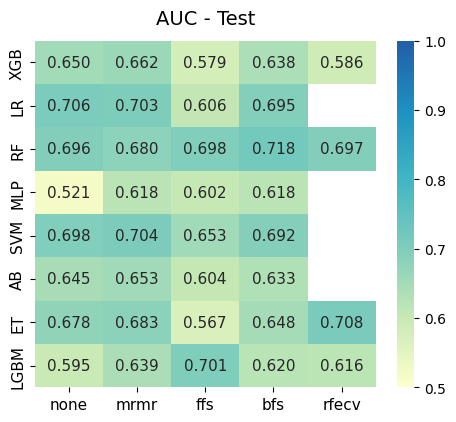

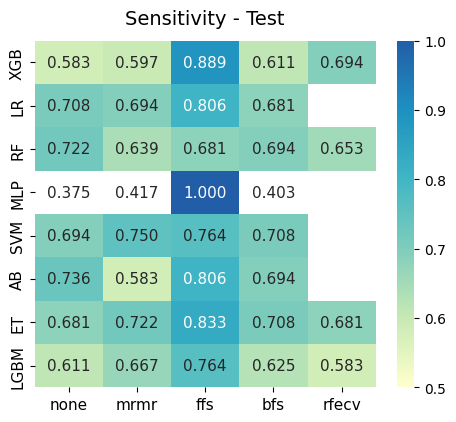

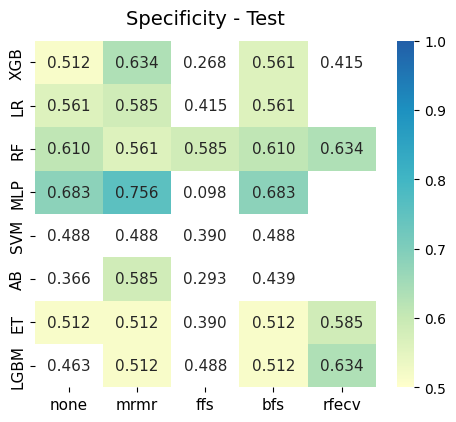

In [17]:
# HEATMAPS
import matplotlib.pyplot as plt

# List of titles
titles = ['f1 score - CV', 'f1 score - Train', 'f1 score - Test', \
          'Accuracy - Test', 'AUC - Test', \
          'Sensitivity - Test', 'Specificity - Test']

file_names = ['f1_cv', 'f1_train', 'f1_test', \
              'test_accuracy', 'test_auc', \
              'test_sensitivity', 'test_specificity']

from matplotlib.colors import LinearSegmentedColormap
colors = ["#ffffcc", "#c7e9b4", "#7fcdbb", "#41b6c4", "#1d91c0", "#225ea8"]  # light yellow, green, blue
light_cmap = LinearSegmentedColormap.from_list("custom_light", colors, N=256)

# Iterate over the dataframes and titles
for i, (df, title, file_name) in enumerate(zip(dataframes, titles, file_names)):
    plt.figure(figsize=(5.5, 4.5))
    heatmap = sns.heatmap(df, vmin=0.5, vmax=1, fmt='.3f', annot=True, annot_kws={'fontsize': 11}, cmap=light_cmap,
                          mask=df<0.5)
    # Overlay white cells for values < 0.5, still showing the annotation
    sns.heatmap(df, vmin=0.5, vmax=1, fmt='.3f', annot=True, annot_kws={'fontsize': 11},
                cmap=['white'], mask=df>=0.5, cbar=False, ax=plt.gca())
    heatmap.set_title(title, fontdict={'fontsize':14}, pad=12)
    heatmap.set_xticklabels(heatmap.get_xmajorticklabels(), fontsize = 11)
    heatmap.set_yticklabels(heatmap.get_ymajorticklabels(), fontsize = 11)
    
    path = f'Results/{file_name}.png'
    fig = heatmap.get_figure()
    if save_output:
        fig.savefig(path, format='png', bbox_inches='tight', dpi=300)